Clustering

In [1]:
from sklearn.datasets import load_iris
data = load_iris()
X = data.data
y = data.target
print(X[:6,:])

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]]


In [2]:
data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

C:\Users\91911\AppData\Local\Temp\ipykernel_21496\3658822962.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


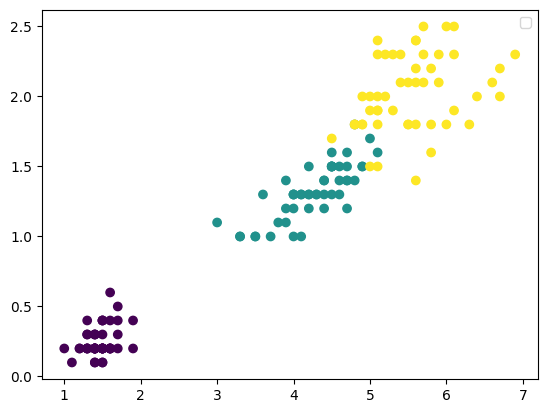

In [3]:
import matplotlib.pyplot as plt
plt.scatter(X[:,2],X[:,3],c =y)
plt.legend()
plt.show()

K Means Clustering

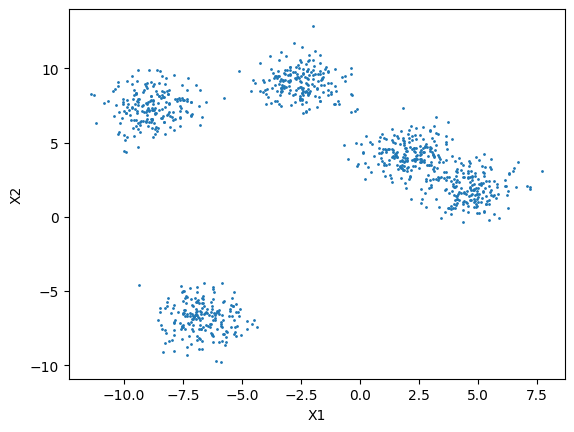

In [4]:
from sklearn.datasets import make_blobs
X,y = make_blobs(n_samples=1000,centers =5 ,random_state = 42)
plt.scatter(X[:,0],X[:,1],s = 1)
plt.xlabel("X1")
plt.ylabel("X2")
plt.show()

In [5]:
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters = 5)
y_pred = kmeans.fit_predict(X)

In [6]:
kmeans.cluster_centers_

array([[ 2.01603476,  4.27139248],
       [-6.68630691, -6.81139455],
       [-8.80798056,  7.40425704],
       [-2.50265159,  9.03963769],
       [ 4.65960568,  1.89528052]])

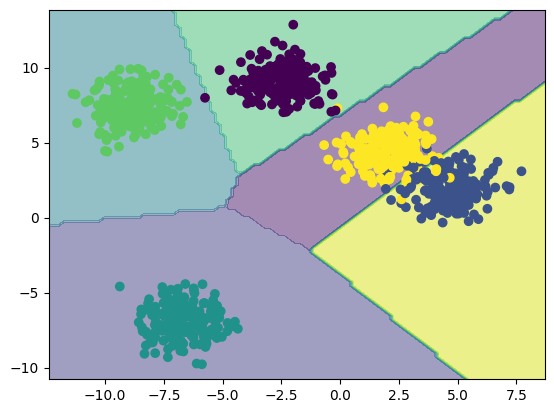

In [7]:
import numpy as np

X0_min , X0_max = X[:,0].min() - 1 , X[:,0].max() + 1
X1_min , X1_max = X[:,1].min() - 1 , X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min,X1_max,100)
)

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = kmeans.predict(X_new)

y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = 0.5)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

Centroid Initialization Methods

If you happen to know approximately where the centroids should be (e.g., if you ran
another clustering algorithm earlier), then you can set the init hyperparameter to a
NumPy array containing the list of centroids, and set n_init to 1:


good_init = np.array([[-3, 3], [-3, 2], [-3, 1], [-1, 2], [0, 2]])<br><br>
kmeans = KMeans(n_clusters=5, init=good_init, n_init=1)


Mini-Batch K-Means

In [8]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters = 5)
minibatch_kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",None
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",'auto'


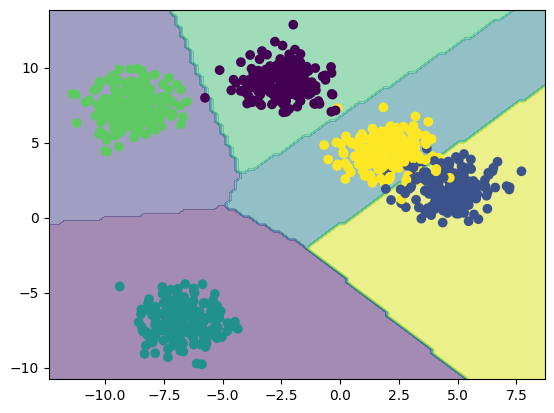

In [9]:
import numpy as np

X0_min , X0_max = X[:,0].min() - 1 , X[:,0].max() + 1
X1_min , X1_max = X[:,1].min() - 1 , X[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(X0_min,X0_max,100),
    np.linspace(X1_min,X1_max,100)
)

X_new = np.c_[xx.ravel(),yy.ravel()]
y_pred = minibatch_kmeans.predict(X_new)

y_pred = y_pred.reshape(xx.shape)

plt.contourf(xx,yy,y_pred,alpha = 0.5)
plt.scatter(X[:,0],X[:,1],c=y)
plt.show()

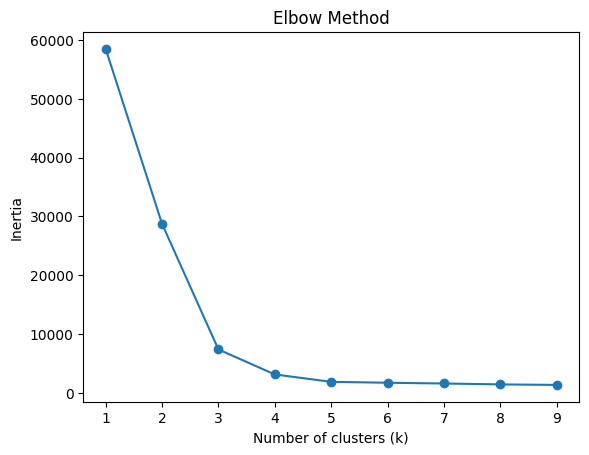

In [10]:
inertias = []
k_values = range(1,10)

for k in k_values:
    kmeans = KMeans(n_clusters = k, random_state =42)
    kmeans.fit_transform(X)
    inertias.append(kmeans.inertia_)

plt.plot(k_values,inertias, marker = 'o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

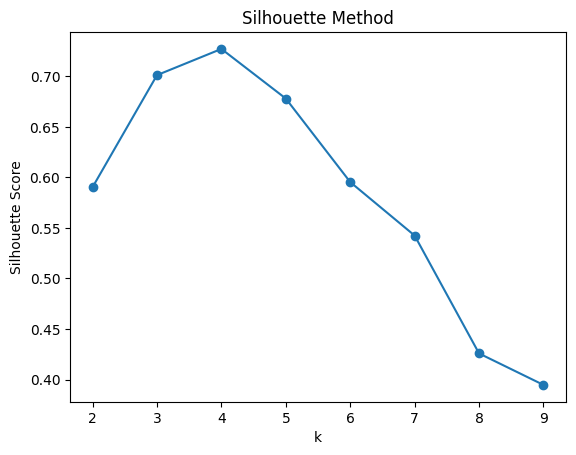

In [14]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []
k_values = range(2, 10) 

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.plot(k_values, scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Method")
plt.show()

In [12]:
y

array([1, 1, 2, 1, 4, 2, 3, 4, 1, 4, 4, 2, 3, 2, 3, 2, 0, 3, 0, 4, 1, 0,
       3, 2, 0, 1, 0, 3, 4, 3, 1, 3, 4, 3, 0, 2, 4, 4, 4, 0, 4, 3, 3, 2,
       3, 2, 1, 1, 0, 2, 1, 3, 2, 0, 0, 0, 0, 2, 2, 0, 1, 3, 2, 4, 2, 1,
       3, 3, 1, 1, 3, 2, 1, 2, 3, 0, 3, 1, 1, 3, 0, 1, 2, 2, 3, 1, 0, 4,
       0, 3, 1, 3, 1, 4, 4, 2, 0, 0, 2, 3, 2, 4, 1, 2, 0, 1, 0, 2, 4, 0,
       0, 1, 2, 2, 3, 0, 3, 2, 0, 4, 2, 0, 2, 2, 2, 2, 3, 2, 0, 1, 1, 3,
       1, 4, 2, 4, 1, 4, 0, 3, 2, 0, 1, 0, 1, 1, 2, 1, 1, 4, 3, 2, 1, 1,
       0, 1, 1, 0, 3, 1, 3, 1, 3, 0, 3, 1, 4, 3, 0, 1, 2, 0, 0, 2, 4, 2,
       3, 2, 1, 4, 1, 0, 1, 3, 4, 4, 1, 2, 3, 0, 3, 0, 1, 4, 1, 0, 4, 2,
       0, 1, 2, 3, 2, 2, 3, 4, 4, 0, 4, 1, 0, 3, 3, 4, 1, 2, 2, 2, 3, 4,
       2, 2, 0, 2, 0, 4, 2, 4, 1, 1, 0, 1, 0, 1, 1, 3, 0, 0, 3, 1, 4, 3,
       2, 4, 2, 2, 2, 2, 3, 4, 2, 2, 4, 1, 4, 0, 3, 1, 1, 0, 1, 4, 1, 3,
       1, 3, 3, 3, 2, 2, 1, 1, 3, 4, 0, 4, 2, 0, 3, 4, 4, 2, 1, 4, 2, 3,
       1, 1, 1, 0, 4, 0, 3, 4, 1, 3, 4, 4, 0, 4, 3,